# 🔥 연속 프레임 필터 효과 검증 — Before/After 비교 테스트

## 목적
- **Before**: 필터 없이 매 프레임 탐지 결과를 그대로 사용했을 때의 탐지 횟수
- **After**: 연속 5프레임 이상 탐지해야 알람으로 인정하는 필터를 적용했을 때의 탐지 횟수
- 두 결과를 비교하여 **오탐 감소율**을 정량적으로 측정

## 테스트 환경
| 항목 | 값 |
|------|----|
| 모델 | YOLOv8n (Fine-tuned) |
| GPU | RTX 4060 Ti 8GB (CUDA) |
| Threshold | 0.10 |
| 테스트 영상 | demo_20260305_180347_[서해안선]_광명역.mp4 |
| 연속 프레임 기준 | 5~10프레임 (조절 가능) |

In [1]:
# =============================================================================
# 셀 1: 라이브러리 import
# =============================================================================

from ultralytics import YOLO          # YOLOv8 모델 로드 및 추론용
import cv2                            # OpenCV — 영상 프레임 읽기용
from pathlib import Path              # 파일 경로 처리용
import numpy as np                    # 숫자 계산용 (평균 등)
import time                           # 시간 측정용
import matplotlib.pyplot as plt       # 그래프 시각화용
import matplotlib                     # matplotlib 한글 설정용

# 한글 폰트 설정 (그래프에서 한글이 깨지지 않도록)
matplotlib.rcParams["font.family"] = "Malgun Gothic"   # 윈도우 기본 한글 폰트
matplotlib.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

print("✅ 라이브러리 로드 완료!")       # 로드 확인 메시지


✅ 라이브러리 로드 완료!


In [4]:
# =============================================================================
# 셀 2: 설정값 
# =============================================================================

# 프로젝트 루트 경로
PROJECT_ROOT = Path(r"N:\개인\이수빈\3.13_Mini_Project")   # 프로젝트 최상위 폴더

# 모델 경로 (Fine-tuned YOLOv8n)
MODEL_PATH = PROJECT_ROOT / "results" / "yolov8n_tuned" / "weights" / "best.pt"  # 학습된 모델 가중치

# 테스트 영상 경로
VIDEO_PATH = PROJECT_ROOT / "DATASET" / "테스트영상" / "2.mp4"  # 테스트용 영상 파일

# 신뢰도 임계값 (Threshold)
CONF_THRESHOLD = 0.10                 # YOLO 탐지 기준 — 10% 이상이면 탐지로 판단

# ★ 연속 프레임 기준 — 이 값을 바꾸면 필터 강도가 바뀜
CONSECUTIVE_FRAMES = 5                # 여기서 연속 프레임 수 조절 가능

# GPU 설정
DEVICE = 0                            # 0 = 첫 번째 GPU (RTX 4060 Ti)

# 설정값 확인 출력
print(f"📁 프로젝트 경로: {PROJECT_ROOT}")           # 경로 확인
print(f"🧠 모델 경로: {MODEL_PATH}")                 # 모델 파일 확인
print(f"🎬 영상 경로: {VIDEO_PATH}")                 # 영상 파일 확인
print(f"🎯 Threshold: {CONF_THRESHOLD}")             # 임계값 확인
print(f"🔢 연속 프레임 기준: {CONSECUTIVE_FRAMES}")    # 연속 프레임 수 확인
print(f"🖥️ GPU 디바이스: {DEVICE}")                  # GPU 번호 확인


📁 프로젝트 경로: N:\개인\이수빈\3.13_Mini_Project
🧠 모델 경로: N:\개인\이수빈\3.13_Mini_Project\results\yolov8n_tuned\weights\best.pt
🎬 영상 경로: N:\개인\이수빈\3.13_Mini_Project\DATASET\테스트영상\2.mp4
🎯 Threshold: 0.1
🔢 연속 프레임 기준: 5
🖥️ GPU 디바이스: 0


In [5]:
# =============================================================================
# 셀 3: 모델 로드
# =============================================================================

print("📦 모델 로드 중...")                          # 로딩 시작 메시지
model = YOLO(str(MODEL_PATH))                       # YOLO 모델 객체 생성 (가중치 로드)
print(f"✅ 모델 로드 완료: {MODEL_PATH.name}")        # 로드 완료 메시지 (파일명만 출력)


📦 모델 로드 중...
✅ 모델 로드 완료: best.pt


In [6]:
# =============================================================================
# 셀 4: 영상 정보 확인
# =============================================================================

cap = cv2.VideoCapture(str(VIDEO_PATH))             # 영상 파일 열기

if not cap.isOpened():                              # 영상 열기 실패 시
    print("❌ 영상 파일을 열 수 없습니다!")           # 에러 메시지
    print(f"   경로 확인: {VIDEO_PATH}")             # 경로 출력
else:                                               # 영상 열기 성공 시
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))   # 영상 너비 (픽셀)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # 영상 높이 (픽셀)
    fps = cap.get(cv2.CAP_PROP_FPS)                  # 초당 프레임 수 (FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임 수
    duration = total_frames / fps if fps > 0 else 0  # 영상 길이 (초)

    print(f"📹 영상 정보:")                           # 정보 제목
    print(f"   해상도: {width}x{height}")             # 해상도 출력
    print(f"   FPS: {fps:.1f}")                      # FPS 출력
    print(f"   총 프레임 수: {total_frames:,}")        # 총 프레임 수 (천 단위 쉼표)
    print(f"   영상 길이: {duration:.1f}초 ({duration/60:.1f}분)")  # 길이 출력

cap.release()                                       # 영상 파일 닫기


📹 영상 정보:
   해상도: 1920x1080
   FPS: 30.0
   총 프레임 수: 37,434
   영상 길이: 1247.8초 (20.8분)


## 🔵 Before 테스트 — 필터 없음 (원본)

**방법**: 영상의 모든 프레임에 YOLO 추론을 실행하고, 탐지가 1번이라도 발생하면 바로 "탐지"로 카운트

**기대 결과**: 순간 오탐(태양 반사, 헤드라이트 등)이 포함되어 탐지 횟수가 높을 것

**기록하는 것**:
- 탐지가 발생한 프레임 번호
- 해당 프레임의 시점(초)
- 총 탐지 횟수


In [7]:
# =============================================================================
# 셀 5: Before 테스트 — 필터 없이 모든 탐지 기록
# =============================================================================

print("=" * 60)                                     # 구분선 출력
print("🔵 Before 테스트 시작 (필터 없음)")            # 테스트 시작 메시지
print("=" * 60)                                     # 구분선 출력

cap = cv2.VideoCapture(str(VIDEO_PATH))             # 영상 파일 열기
fps = cap.get(cv2.CAP_PROP_FPS)                     # FPS 값 가져오기
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임 수 가져오기

# Before 결과 저장용 리스트
before_detections = []                              # 탐지 발생 프레임 정보 리스트 (비어있는 상태로 시작)
before_frame_results = []                           # 매 프레임의 탐지 여부 (True/False) 리스트

frame_idx = 0                                       # 현재 프레임 번호 (0부터 시작)
start_time = time.time()                            # 테스트 시작 시각 기록

# 모든 프레임을 순회하며 추론
while True:                                         # 무한 루프 (영상 끝까지)
    ret, frame = cap.read()                         # 프레임 1장 읽기 (ret=성공여부, frame=이미지)
    if not ret:                                     # 프레임 읽기 실패 시 (영상 끝)
        break                                       # 루프 종료

    # YOLO 추론 실행
    results = model.predict(                        # 모델로 예측 실행
        frame,                                      # 입력 이미지 (현재 프레임)
        conf=CONF_THRESHOLD,                        # 신뢰도 임계값 (0.10)
        imgsz=640,                                  # 입력 이미지 크기
        device=DEVICE,                              # GPU 사용 (device=0)
        verbose=False                               # 로그 출력 안 함 (깔끔하게)
    )

    # 탐지 결과 확인
    num_boxes = len(results[0].boxes)                # 이 프레임에서 탐지된 바운딩박스 수
    detected = num_boxes > 0                        # 1개 이상 탐지되면 True
    before_frame_results.append(detected)           # 이 프레임의 탐지 여부를 리스트에 추가

    # 탐지가 발생했으면 기록
    if detected:                                    # 이 프레임에서 탐지됐으면
        time_sec = frame_idx / fps if fps > 0 else 0  # 현재 프레임의 시점 (초 단위)
        before_detections.append({                  # 탐지 정보를 딕셔너리로 저장
            "frame": frame_idx,                     # 프레임 번호
            "time_sec": round(time_sec, 2),         # 시점 (초, 소수점 2자리)
            "num_boxes": num_boxes                  # 탐지된 박스 수
        })

    frame_idx += 1                                  # 프레임 번호 1 증가

    # 진행 상황 출력 (500프레임마다)
    if frame_idx % 500 == 0:                        # 500프레임마다 한 번
        progress = frame_idx / total_frames * 100   # 진행률 계산 (%)
        print(f"   진행: {frame_idx:,}/{total_frames:,} ({progress:.1f}%)")  # 진행률 출력

cap.release()                                       # 영상 파일 닫기
elapsed = time.time() - start_time                  # 소요 시간 계산

# Before 결과 출력
print(f"\n📊 Before 결과:")                          # 결과 제목
print(f"   총 프레임: {frame_idx:,}")                 # 처리한 총 프레임 수
print(f"   탐지 프레임: {len(before_detections):,}")   # 탐지가 발생한 프레임 수
print(f"   소요 시간: {elapsed:.1f}초")               # 처리 소요 시간

# 탐지 시점 출력 (처음 10개만)
if before_detections:                               # 탐지가 1건이라도 있으면
    print(f"\n   탐지 시점 (처음 10개):")              # 시점 목록 제목
    for det in before_detections[:10]:               # 처음 10개만 출력
        print(f"     프레임 {det['frame']:>6} | {det['time_sec']:>8.2f}초 | 박스 {det['num_boxes']}개")  # 프레임 정보 출력
    if len(before_detections) > 10:                  # 10개 초과 시
        print(f"     ... 외 {len(before_detections) - 10}건")  # 나머지 개수 표시


🔵 Before 테스트 시작 (필터 없음)
   진행: 500/37,434 (1.3%)
   진행: 1,000/37,434 (2.7%)
   진행: 1,500/37,434 (4.0%)
   진행: 2,000/37,434 (5.3%)
   진행: 2,500/37,434 (6.7%)
   진행: 3,000/37,434 (8.0%)
   진행: 3,500/37,434 (9.3%)
   진행: 4,000/37,434 (10.7%)
   진행: 4,500/37,434 (12.0%)
   진행: 5,000/37,434 (13.4%)
   진행: 5,500/37,434 (14.7%)
   진행: 6,000/37,434 (16.0%)
   진행: 6,500/37,434 (17.4%)
   진행: 7,000/37,434 (18.7%)
   진행: 7,500/37,434 (20.0%)
   진행: 8,000/37,434 (21.4%)
   진행: 8,500/37,434 (22.7%)
   진행: 9,000/37,434 (24.0%)
   진행: 9,500/37,434 (25.4%)
   진행: 10,000/37,434 (26.7%)
   진행: 10,500/37,434 (28.0%)
   진행: 11,000/37,434 (29.4%)
   진행: 11,500/37,434 (30.7%)
   진행: 12,000/37,434 (32.1%)
   진행: 12,500/37,434 (33.4%)
   진행: 13,000/37,434 (34.7%)
   진행: 13,500/37,434 (36.1%)
   진행: 14,000/37,434 (37.4%)
   진행: 14,500/37,434 (38.7%)
   진행: 15,000/37,434 (40.1%)
   진행: 15,500/37,434 (41.4%)
   진행: 16,000/37,434 (42.7%)
   진행: 16,500/37,434 (44.1%)
   진행: 17,000/37,434 (45.4%)
   진행: 17,500/37,4

## 🟢 After 테스트 — 연속 5프레임 필터 적용

**방법**: 같은 영상에서 연속 N프레임(기본 5) 이상 탐지가 지속될 때만 "알람"으로 카운트

**핵심 로직**:
- 탐지 시 → 카운터 +1
- 미탐지 시 → 카운터 0으로 리셋
- 카운터 ≥ 5이면 → "알람 시작" (이 때만 카운트)

**기대 결과**: 순간 오탐(1~3프레임)이 걸러져서 탐지 횟수가 대폭 감소할 것


In [8]:
# =============================================================================
# 셀 6: After 테스트 — 연속 5프레임 필터 적용
# =============================================================================

print("=" * 60)                                     # 구분선 출력
print(f"🟢 After 테스트 시작 (연속 {CONSECUTIVE_FRAMES}프레임 필터)")  # 테스트 시작 메시지
print("=" * 60)                                     # 구분선 출력

# ★ Before에서 이미 매 프레임 추론 결과를 저장했으므로 재사용!
# before_frame_results = [True, False, True, True, ...] 형태의 리스트
# → 영상을 다시 읽고 추론할 필요 없이, 이 리스트만 보고 필터링 가능

# After 결과 저장용
after_alarms = []                                   # 알람 발생 시점 리스트
consecutive_count = 0                               # 연속 탐지 카운터 (0부터 시작)
alarm_active = False                                # 현재 알람 상태 (False = 비활성)
alarm_id = 0                                        # 알람 번호 (몇 번째 알람인지)

# 모든 프레임 결과를 순회하며 필터 적용
for i, detected in enumerate(before_frame_results): # i=프레임 번호, detected=탐지 여부

    if detected:                                    # 이 프레임에서 탐지됐으면
        consecutive_count += 1                      # 연속 카운터 +1
    else:                                           # 이 프레임에서 탐지 안 됐으면
        consecutive_count = 0                       # 카운터 0으로 리셋!
        alarm_active = False                        # 알람 비활성화

    # ★ 연속 N프레임 이상이면 알람 발생                  # 여기서 연속 프레임 수 조절 가능
    if consecutive_count >= CONSECUTIVE_FRAMES:      # 카운터가 기준값 이상이면
        if not alarm_active:                        # 아직 알람이 비활성이면 (새로운 알람)
            alarm_active = True                     # 알람 활성화
            alarm_id += 1                           # 알람 번호 +1
            time_sec = i / fps if fps > 0 else 0    # 이 프레임의 시점 (초)
            after_alarms.append({                   # 알람 정보 저장
                "alarm_id": alarm_id,               # 알람 번호
                "start_frame": i,                   # 알람 시작 프레임
                "time_sec": round(time_sec, 2),     # 시작 시점 (초)
                "consecutive_at_start": consecutive_count  # 연속 프레임 수
            })
            print(f"   🚨 알람 #{alarm_id} 발생! 프레임 {i} ({time_sec:.2f}초) — 연속 {consecutive_count}프레임")  # 알람 발생 메시지

# After 결과 출력
print(f"\n📊 After 결과:")                            # 결과 제목
print(f"   총 프레임: {len(before_frame_results):,}") # 처리한 총 프레임 수
print(f"   알람 발생 횟수: {len(after_alarms)}")       # 알람이 발생한 횟수

# 알람 시점 출력
if after_alarms:                                    # 알람이 1건이라도 있으면
    print(f"\n   알람 시점:")                          # 시점 목록 제목
    for alarm in after_alarms:                      # 모든 알람 정보 출력
        print(f"     알람 #{alarm['alarm_id']} | 프레임 {alarm['start_frame']:>6} | {alarm['time_sec']:>8.2f}초")  # 알람 정보 출력


🟢 After 테스트 시작 (연속 5프레임 필터)
   🚨 알람 #1 발생! 프레임 988 (32.93초) — 연속 5프레임
   🚨 알람 #2 발생! 프레임 2896 (96.53초) — 연속 5프레임
   🚨 알람 #3 발생! 프레임 3926 (130.87초) — 연속 5프레임
   🚨 알람 #4 발생! 프레임 4376 (145.87초) — 연속 5프레임
   🚨 알람 #5 발생! 프레임 4460 (148.67초) — 연속 5프레임
   🚨 알람 #6 발생! 프레임 5238 (174.60초) — 연속 5프레임
   🚨 알람 #7 발생! 프레임 8466 (282.20초) — 연속 5프레임
   🚨 알람 #8 발생! 프레임 9248 (308.27초) — 연속 5프레임
   🚨 알람 #9 발생! 프레임 13730 (457.67초) — 연속 5프레임
   🚨 알람 #10 발생! 프레임 29668 (988.93초) — 연속 5프레임

📊 After 결과:
   총 프레임: 37,434
   알람 발생 횟수: 10

   알람 시점:
     알람 #1 | 프레임    988 |    32.93초
     알람 #2 | 프레임   2896 |    96.53초
     알람 #3 | 프레임   3926 |   130.87초
     알람 #4 | 프레임   4376 |   145.87초
     알람 #5 | 프레임   4460 |   148.67초
     알람 #6 | 프레임   5238 |   174.60초
     알람 #7 | 프레임   8466 |   282.20초
     알람 #8 | 프레임   9248 |   308.27초
     알람 #9 | 프레임  13730 |   457.67초
     알람 #10 | 프레임  29668 |   988.93초


In [9]:
# =============================================================================
# 추가 셀: 알람 발생 시점 bbox 이미지 저장
# → 19번 노트북의 셀 6(After 테스트) 실행 후에 이 셀을 실행
# → after_alarms 리스트가 메모리에 있어야 합니다
# =============================================================================

import os  # 폴더 생성용

# bbox 이미지 저장 폴더 생성
BBOX_DIR = PROJECT_ROOT / "evaluation" / "temporal_filter_bbox"  # 저장 경로
BBOX_DIR.mkdir(parents=True, exist_ok=True)  # 폴더가 없으면 생성

print(f"📁 bbox 이미지 저장 폴더: {BBOX_DIR}")  # 저장 경로 출력
print(f"📊 저장할 알람 수: {len(after_alarms)}건")  # 알람 수 출력
print(f"{'='*60}")  # 구분선

# 알람 시점의 프레임 번호 목록 추출
# after_alarms에서 각 알람의 start_frame을 꺼냄
alarm_frames = {a['start_frame']: a for a in after_alarms}  # {프레임번호: 알람정보} 딕셔너리

# 영상을 다시 열어서 해당 프레임만 추출
cap = cv2.VideoCapture(str(VIDEO_PATH))  # 영상 파일 열기
fps = cap.get(cv2.CAP_PROP_FPS)  # FPS 가져오기
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 총 프레임 수

# 알람 프레임 중 마지막 프레임까지만 읽으면 됨 (효율성)
max_alarm_frame = max(alarm_frames.keys())  # 가장 마지막 알람 프레임 번호
print(f"🎬 마지막 알람 프레임: {max_alarm_frame} (총 {total_frames} 중)")  # 진행 범위

saved_count = 0  # 저장된 이미지 수
frame_idx = 0  # 현재 프레임 번호

print(f"🔍 bbox 이미지 추출 중...")  # 시작 메시지

while True:  # 영상 프레임 순회
    ret, frame = cap.read()  # 프레임 1장 읽기
    if not ret:  # 영상 끝이면
        break  # 루프 종료

    # 이 프레임이 알람 시점인지 확인
    if frame_idx in alarm_frames:  # 현재 프레임이 알람 프레임이면
        alarm_info = alarm_frames[frame_idx]  # 알람 정보 가져오기
        alarm_id = alarm_info['alarm_id']  # 알람 번호
        time_sec = alarm_info['time_sec']  # 시점 (초)

        # YOLO 추론 실행 (bbox를 그리기 위해)
        results = model.predict(  # 모델 추론
            frame,  # 입력 이미지
            conf=CONF_THRESHOLD,  # 신뢰도 임계값
            imgsz=640,  # 입력 크기
            device=DEVICE,  # GPU
            verbose=False  # 로그 끄기
        )

        # bbox가 그려진 이미지 생성 (YOLO 내장 기능)
        bbox_frame = results[0].plot()  # bbox + confidence 표시된 이미지

        # 상단에 알람 정보 텍스트 추가
        h_img, w_img = bbox_frame.shape[:2]  # 이미지 크기
        # 반투명 배경 바
        overlay = bbox_frame.copy()  # 이미지 복사
        cv2.rectangle(overlay, (0, 0), (w_img, 50), (0, 0, 180), -1)  # 빨간 배경
        cv2.addWeighted(overlay, 0.6, bbox_frame, 0.4, 0, bbox_frame)  # 반투명 합성

        # 알람 정보 텍스트
        cv2.putText(bbox_frame,  # 이미지에 텍스트 추가
                    f"ALARM #{alarm_id} | Frame {frame_idx} | {time_sec:.2f}s",  # 텍스트 내용
                    (10, 20),  # 위치 (x, y)
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)  # 폰트, 크기, 색상, 두께

        # confidence 값 표시
        if len(results[0].boxes) > 0:  # 탐지된 박스가 있으면
            confs = results[0].boxes.conf.cpu().numpy()  # confidence 배열
            max_conf = float(np.max(confs))  # 최대 confidence
            num_boxes = len(results[0].boxes)  # 박스 수
            cv2.putText(bbox_frame,  # 두 번째 줄
                        f"Boxes: {num_boxes} | Max Conf: {max_conf:.3f} | Threshold: {CONF_THRESHOLD}",
                        (10, 42),  # 위치
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 200), 1)  # 폰트

        # 파일명: alarm번호_프레임번호_시간.jpg
        filename = f"alarm{alarm_id:02d}_frame{frame_idx:06d}_{time_sec:.1f}s.jpg"  # 파일명 생성
        save_path = BBOX_DIR / filename  # 전체 경로
        cv2.imwrite(str(save_path), bbox_frame)  # 이미지 저장

        saved_count += 1  # 저장 카운트 +1
        print(f"  ✅ 알람 #{alarm_id:>2} | 프레임 {frame_idx:>6} | {time_sec:>8.2f}초 | conf {max_conf:.3f} | 박스 {num_boxes}개 → {filename}")

    frame_idx += 1  # 다음 프레임

    # 마지막 알람 프레임을 지나면 종료 (나머지는 읽을 필요 없음)
    if frame_idx > max_alarm_frame:  # 효율적 종료
        break

cap.release()  # 영상 닫기

print(f"{'='*60}")  # 구분선
print(f"💾 bbox 이미지 {saved_count}장 저장 완료!")  # 완료 메시지
print(f"📁 저장 위치: {BBOX_DIR}")  # 저장 경로
print(f"{'='*60}")  # 구분선


📁 bbox 이미지 저장 폴더: N:\개인\이수빈\3.13_Mini_Project\evaluation\temporal_filter_bbox
📊 저장할 알람 수: 10건
🎬 마지막 알람 프레임: 29668 (총 37434 중)
🔍 bbox 이미지 추출 중...
  ✅ 알람 # 1 | 프레임    988 |    32.93초 | conf 0.111 | 박스 1개 → alarm01_frame000988_32.9s.jpg
  ✅ 알람 # 2 | 프레임   2896 |    96.53초 | conf 0.151 | 박스 1개 → alarm02_frame002896_96.5s.jpg
  ✅ 알람 # 3 | 프레임   3926 |   130.87초 | conf 0.152 | 박스 2개 → alarm03_frame003926_130.9s.jpg
  ✅ 알람 # 4 | 프레임   4376 |   145.87초 | conf 0.146 | 박스 1개 → alarm04_frame004376_145.9s.jpg
  ✅ 알람 # 5 | 프레임   4460 |   148.67초 | conf 0.208 | 박스 2개 → alarm05_frame004460_148.7s.jpg
  ✅ 알람 # 6 | 프레임   5238 |   174.60초 | conf 0.147 | 박스 1개 → alarm06_frame005238_174.6s.jpg
  ✅ 알람 # 7 | 프레임   8466 |   282.20초 | conf 0.155 | 박스 1개 → alarm07_frame008466_282.2s.jpg
  ✅ 알람 # 8 | 프레임   9248 |   308.27초 | conf 0.139 | 박스 1개 → alarm08_frame009248_308.3s.jpg
  ✅ 알람 # 9 | 프레임  13730 |   457.67초 | conf 0.144 | 박스 1개 → alarm09_frame013730_457.7s.jpg
  ✅ 알람 #10 | 프레임  29668 |   988.93초 | conf 0.15

In [11]:
# =============================================================================
# 추가 셀 (선택): Before 첫 탐지 10건 bbox 저장
# → 필터 없이 탐지된 것들이 어떤 모습인지 확인용
# =============================================================================

# Before 탐지 중 처음 10건의 프레임 번호
before_first10 = before_detections[:10]  # 처음 10건 가져오기
before_frames_to_save = {d['frame']: d for d in before_first10}  # 딕셔너리로 변환

# Before bbox 저장 폴더
BEFORE_DIR = BBOX_DIR / "before_samples"  # 하위 폴더
BEFORE_DIR.mkdir(parents=True, exist_ok=True)  # 폴더 생성

cap = cv2.VideoCapture(str(VIDEO_PATH))  # 영상 열기
max_before_frame = max(before_frames_to_save.keys())  # 마지막 프레임 번호

frame_idx = 0  # 프레임 카운터
saved = 0  # 저장 카운터

print(f"🔍 Before 첫 탐지 10건 bbox 추출 중...")  # 시작

while True:
    ret, frame = cap.read()  # 프레임 읽기
    if not ret:  # 끝이면
        break

    if frame_idx in before_frames_to_save:  # 저장 대상 프레임이면
        det = before_frames_to_save[frame_idx]  # 탐지 정보

        results = model.predict(frame, conf=CONF_THRESHOLD, imgsz=640,  # 추론
                                device=DEVICE, verbose=False)
        bbox_frame = results[0].plot()  # bbox 이미지

        # 상단 텍스트
        h_img, w_img = bbox_frame.shape[:2]
        overlay = bbox_frame.copy()
        cv2.rectangle(overlay, (0, 0), (w_img, 35), (180, 100, 0), -1)  # 주황 배경
        cv2.addWeighted(overlay, 0.6, bbox_frame, 0.4, 0, bbox_frame)
        cv2.putText(bbox_frame,
                    f"BEFORE (no filter) | Frame {frame_idx} | {det['time_sec']:.2f}s | Boxes: {det['num_boxes']}",
                    (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        filename = f"before_frame{frame_idx:06d}_{det['time_sec']:.1f}s.jpg"  # 파일명
        cv2.imwrite(str(BEFORE_DIR / filename), bbox_frame)  # 저장
        saved += 1
        print(f"  ✅ Before #{saved} | 프레임 {frame_idx:>6} | {det['time_sec']:>7.2f}초 | 박스 {det['num_boxes']}개")

    frame_idx += 1
    if frame_idx > max_before_frame:  # 효율적 종료
        break

cap.release()  # 영상 닫기

print(f"💾 Before 샘플 {saved}장 저장: {BEFORE_DIR}")

🔍 Before 첫 탐지 10건 bbox 추출 중...
  ✅ Before #1 | 프레임    944 |   31.47초 | 박스 1개
  ✅ Before #2 | 프레임    945 |   31.50초 | 박스 1개
  ✅ Before #3 | 프레임    946 |   31.53초 | 박스 1개
  ✅ Before #4 | 프레임    947 |   31.57초 | 박스 1개
  ✅ Before #5 | 프레임    958 |   31.93초 | 박스 1개
  ✅ Before #6 | 프레임    960 |   32.00초 | 박스 1개
  ✅ Before #7 | 프레임    961 |   32.03초 | 박스 1개
  ✅ Before #8 | 프레임    966 |   32.20초 | 박스 1개
  ✅ Before #9 | 프레임    967 |   32.23초 | 박스 1개
  ✅ Before #10 | 프레임    968 |   32.27초 | 박스 1개
💾 Before 샘플 10장 저장: N:\개인\이수빈\3.13_Mini_Project\evaluation\temporal_filter_bbox\before_samples


## 📊 결과 비교

Before(필터 없음)와 After(연속 5프레임 필터)의 탐지 횟수를 비교하여:
- **감소율(%)** 을 계산하고
- **타임라인 그래프**로 시각화합니다


In [16]:
# =============================================================================
# 셀 7: 결과 비교 — Before vs After
# =============================================================================

# Before: 개별 프레임 탐지 횟수 → "탐지 이벤트" 단위로 그룹핑
# (연속된 탐지 프레임들을 하나의 "이벤트"로 묶기)
before_events = []                                  # Before 탐지 이벤트 리스트
in_event = False                                    # 현재 이벤트 진행 중인지 여부

for i, detected in enumerate(before_frame_results): # 모든 프레임 결과 순회
    if detected and not in_event:                   # 탐지 시작 (이전에 탐지 안 되다가 처음 탐지)
        in_event = True                             # 이벤트 시작 표시
        time_sec = i / fps if fps > 0 else 0        # 시작 시점 (초)
        before_events.append({                      # 이벤트 정보 저장
            "start_frame": i,                       # 이벤트 시작 프레임
            "time_sec": round(time_sec, 2)          # 시작 시점 (초)
        })
    elif not detected:                              # 탐지 안 되면
        in_event = False                            # 이벤트 종료 표시

# 감소율 계산
before_count = len(before_events)                   # Before 탐지 이벤트 수
after_count = len(after_alarms)                     # After 알람 수

if before_count > 0:                                # Before에 탐지가 있었으면
    reduction = (1 - after_count / before_count) * 100  # 감소율 계산 (%)
else:                                               # Before에 탐지가 없었으면
    reduction = 0                                   # 감소율 0

# ========================================
# 결과 출력
# ========================================
print()                                             # 빈 줄
print("=" * 50)                                     # 구분선
print("  연속 프레임 필터 효과 검증 결과")              # 제목
print("=" * 50)                                     # 구분선
print(f"  Before (필터 없음)    : 탐지 {before_count}회")  # Before 결과
print(f"  After  ({CONSECUTIVE_FRAMES}프레임 필터) : 탐지 {after_count}회")  # After 결과
print(f"  감소율               : {reduction:.1f}%")  # 감소율 출력
print("=" * 50)                                     # 구분선

# 상세 비교
print(f"\n📋 상세 비교:")                              # 상세 제목
print(f"  총 프레임 수: {len(before_frame_results):,}")  # 총 프레임 수
print(f"  탐지 프레임 수: {sum(before_frame_results):,} ({sum(before_frame_results)/len(before_frame_results)*100:.1f}%)")  # 탐지 프레임 비율
print(f"  Before 이벤트: {before_count}회 (개별 프레임 기반)")  # Before 이벤트 수
print(f"  After 알람: {after_count}회 (연속 {CONSECUTIVE_FRAMES}프레임 기반)")  # After 알람 수
print(f"  제거된 오탐: {before_count - after_count}회")  # 제거된 수
print(f"  감소율: {reduction:.1f}%")                  # 감소율

# 의미 해석
print(f"\n💡 해석:")                                   # 해석 제목
if reduction > 0:                                   # 감소가 있었으면
    print(f"  → 연속 {CONSECUTIVE_FRAMES}프레임 필터로 {reduction:.1f}%의 오탐을 제거했습니다!")  # 긍정적 결과
    print(f"  → {before_count - after_count}건의 순간 오탐이 효과적으로 걸러졌습니다.")  # 제거 건수
else:                                               # 감소가 없었으면
    print(f"  → 이 영상에서는 탐지가 모두 연속적이었습니다.")  # 모두 연속 탐지



  연속 프레임 필터 효과 검증 결과
  Before (필터 없음)    : 탐지 181회
  After  (5프레임 필터) : 탐지 40회
  감소율               : 77.9%

📋 상세 비교:
  총 프레임 수: 46,481
  탐지 프레임 수: 981 (2.1%)
  Before 이벤트: 181회 (개별 프레임 기반)
  After 알람: 40회 (연속 5프레임 기반)
  제거된 오탐: 141회
  감소율: 77.9%

💡 해석:
  → 연속 5프레임 필터로 77.9%의 오탐을 제거했습니다!
  → 141건의 순간 오탐이 효과적으로 걸러졌습니다.


C:\Users\lsb91\AppData\Local\Temp\ipykernel_22772\3673781315.py:54: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                  # 그래프 간 겹침 방지
C:\Users\lsb91\AppData\Local\Temp\ipykernel_22772\3673781315.py:54: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                  # 그래프 간 겹침 방지
C:\Users\lsb91\AppData\Local\Temp\ipykernel_22772\3673781315.py:54: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()                                  # 그래프 간 겹침 방지
C:\Users\lsb91\AppData\Local\Temp\ipykernel_22772\3673781315.py:55: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) Malgun Gothic.
  plt.savefig(str(PROJECT_ROOT / "results" / "temporal_filter_comparison.png"),  # PNG 파일로 저장
C:\Users\lsb91\AppData\Local\Temp\ipykernel_22772\3673781315.py:55: UserWarning: Glyph 128308 

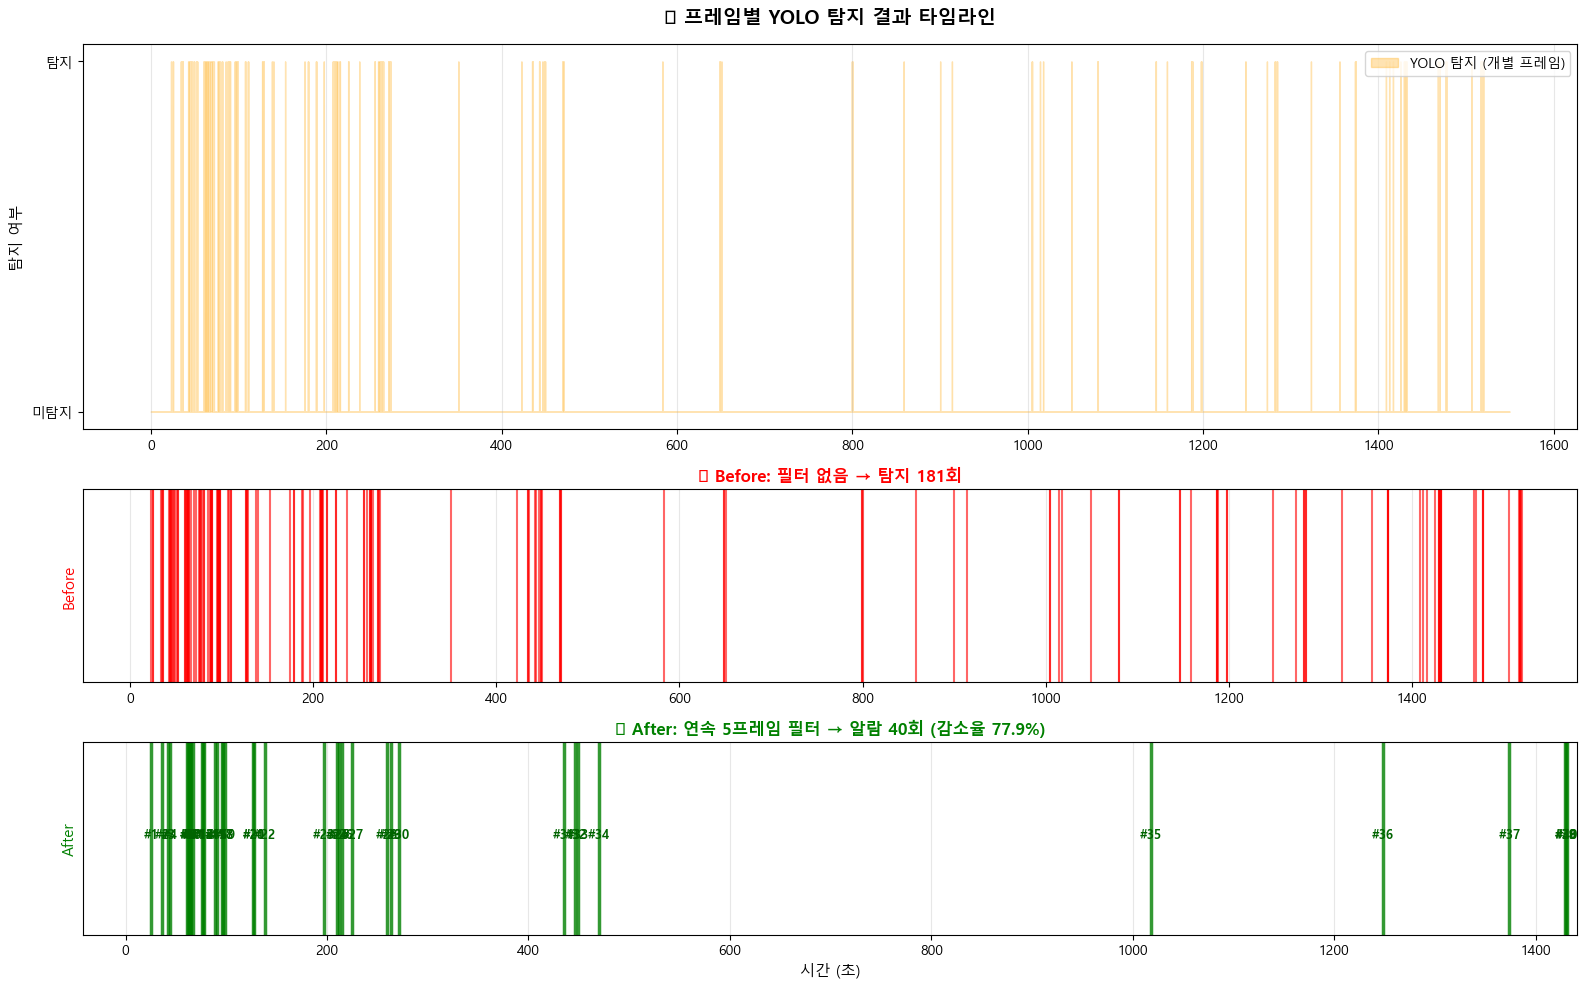


💾 그래프 저장: results/temporal_filter_comparison.png


In [17]:
# =============================================================================
# 셀 8: 타임라인 시각화 — Before vs After 비교 그래프
# =============================================================================

# 그래프 크기 설정
fig, axes = plt.subplots(3, 1, figsize=(16, 10),    # 3행 1열, 가로 16 세로 10 인치
                         gridspec_kw={"height_ratios": [2, 1, 1]})  # 행 높이 비율

# 시간 축 데이터 생성 (초 단위)
time_axis = np.arange(len(before_frame_results)) / fps  # 프레임 번호 → 초 변환

# ─── 그래프 1: 프레임별 탐지 여부 (전체 타임라인) ───
ax1 = axes[0]                                       # 첫 번째 그래프 선택
detection_values = [1 if d else 0 for d in before_frame_results]  # True→1, False→0 변환
ax1.fill_between(time_axis, detection_values,        # 시간 축, 탐지 값
                 alpha=0.3, color="orange",           # 투명도 0.3, 주황색
                 label="YOLO 탐지 (개별 프레임)")       # 범례 텍스트
ax1.set_ylabel("탐지 여부", fontsize=11)              # Y축 레이블
ax1.set_title("🎬 프레임별 YOLO 탐지 결과 타임라인",    # 그래프 제목
              fontsize=14, fontweight="bold", pad=15)  # 크기, 굵기, 패딩
ax1.set_yticks([0, 1])                               # Y축 눈금 (0과 1만)
ax1.set_yticklabels(["미탐지", "탐지"])               # 눈금 라벨
ax1.legend(loc="upper right", fontsize=10)           # 범례 위치
ax1.grid(axis="x", alpha=0.3)                       # X축 그리드 (투명도 0.3)

# ─── 그래프 2: Before 탐지 이벤트 (필터 없음) ───
ax2 = axes[1]                                       # 두 번째 그래프 선택
for event in before_events:                         # 모든 Before 이벤트 순회
    ax2.axvline(x=event["time_sec"],                 # 수직선 그리기
               color="red", alpha=0.6, linewidth=1.5) # 빨간색, 투명도 0.6
ax2.set_ylabel("Before", fontsize=11, color="red")   # Y축 레이블 (빨간색)
ax2.set_title(f"🔴 Before: 필터 없음 → 탐지 {before_count}회",  # 제목
              fontsize=12, fontweight="bold", color="red")  # 빨간색 제목
ax2.set_yticks([])                                   # Y축 눈금 제거
ax2.grid(axis="x", alpha=0.3)                       # X축 그리드

# ─── 그래프 3: After 알람 이벤트 (5프레임 필터) ───
ax3 = axes[2]                                       # 세 번째 그래프 선택
for alarm in after_alarms:                          # 모든 After 알람 순회
    ax3.axvline(x=alarm["time_sec"],                 # 수직선 그리기
               color="green", alpha=0.8, linewidth=2.5)  # 녹색, 투명도 0.8
    ax3.annotate(f'#{alarm["alarm_id"]}',             # 알람 번호 표시
                xy=(alarm["time_sec"], 0.5),          # 위치
                fontsize=9, ha="center",              # 글자 크기, 가운데 정렬
                color="darkgreen", fontweight="bold")  # 진한 녹색, 굵게
ax3.set_ylabel("After", fontsize=11, color="green")  # Y축 레이블 (녹색)
ax3.set_title(f"🟢 After: 연속 {CONSECUTIVE_FRAMES}프레임 필터 → 알람 {after_count}회 (감소율 {reduction:.1f}%)",  # 제목
              fontsize=12, fontweight="bold", color="green")  # 녹색 제목
ax3.set_yticks([])                                   # Y축 눈금 제거
ax3.set_xlabel("시간 (초)", fontsize=11)              # X축 레이블
ax3.grid(axis="x", alpha=0.3)                       # X축 그리드

# 레이아웃 조정
plt.tight_layout()                                  # 그래프 간 겹침 방지
plt.savefig(str(PROJECT_ROOT / "results" / "temporal_filter_comparison.png"),  # PNG 파일로 저장
            dpi=150, bbox_inches="tight")             # 해상도 150dpi, 여백 최소화
plt.show()                                          # 그래프 화면에 표시
print("\n💾 그래프 저장: results/temporal_filter_comparison.png")  # 저장 경로 출력


🔬 다양한 연속 프레임 수별 비교
  연속  1프레임 | 알람 181회 | 감소율   0.0% | 지연 0.03초
  연속  3프레임 | 알람  75회 | 감소율  58.6% | 지연 0.10초
  연속  5프레임 | 알람  40회 | 감소율  77.9% | 지연 0.17초 ★ (현재 설정)
  연속 10프레임 | 알람  19회 | 감소율  89.5% | 지연 0.33초
  연속 15프레임 | 알람  11회 | 감소율  93.9% | 지연 0.50초
  연속 30프레임 | 알람   5회 | 감소율  97.2% | 지연 1.00초


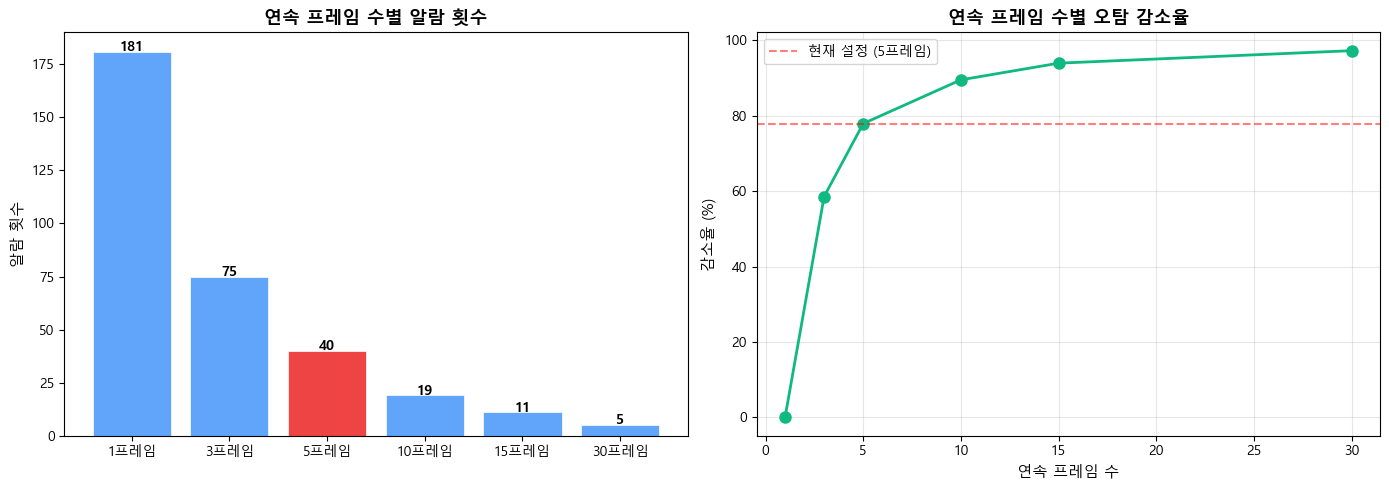


💾 그래프 저장: results/frame_threshold_comparison.png


In [18]:
# =============================================================================
# 셀 9: 다양한 연속 프레임 수 비교 (보너스)
# =============================================================================

print("=" * 60)                                     # 구분선
print("🔬 다양한 연속 프레임 수별 비교")               # 제목
print("=" * 60)                                     # 구분선

# 테스트할 연속 프레임 수 목록
test_thresholds = [1, 3, 5, 10, 15, 30]             # 비교할 프레임 수 리스트
comparison_results = []                             # 결과 저장 리스트

for n_frames in test_thresholds:                    # 각 프레임 수에 대해
    count = 0                                       # 연속 탐지 카운터
    active = False                                  # 알람 활성 상태
    alarm_count = 0                                 # 알람 발생 횟수

    for detected in before_frame_results:           # 모든 프레임 결과 순회
        if detected:                                # 탐지됐으면
            count += 1                              # 카운터 +1
        else:                                       # 탐지 안 됐으면
            count = 0                               # 카운터 리셋
            active = False                          # 알람 비활성

        if count >= n_frames and not active:        # 기준 도달 + 새 알람이면
            active = True                           # 알람 활성화
            alarm_count += 1                        # 알람 횟수 +1

    # 감소율 계산
    red = (1 - alarm_count / before_count) * 100 if before_count > 0 else 0  # 감소율 (%)
    time_delay = n_frames / fps if fps > 0 else 0   # 지연 시간 (초)

    comparison_results.append({                     # 결과 저장
        "frames": n_frames,                         # 프레임 수
        "alarms": alarm_count,                      # 알람 수
        "reduction": red,                           # 감소율
        "delay": time_delay                         # 지연 시간
    })

    # 현재 설정값 표시
    marker = " ★ (현재 설정)" if n_frames == CONSECUTIVE_FRAMES else ""  # 현재 설정 표시
    print(f"  연속 {n_frames:>2}프레임 | 알람 {alarm_count:>3}회 | 감소율 {red:>5.1f}% | 지연 {time_delay:.2f}초{marker}")  # 결과 출력

# ─── 비교 그래프 ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # 1행 2열 그래프

# 왼쪽: 알람 횟수
frames_list = [r["frames"] for r in comparison_results]  # X축: 프레임 수
alarms_list = [r["alarms"] for r in comparison_results]  # Y축: 알람 수
colors = ["#ef4444" if f == CONSECUTIVE_FRAMES else "#60a5fa" for f in frames_list]  # 현재 설정 빨간색
ax1.bar(range(len(frames_list)), alarms_list,        # 막대 그래프
        color=colors, edgecolor="white", linewidth=0.5)  # 색상, 테두리
ax1.set_xticks(range(len(frames_list)))               # X축 눈금 위치
ax1.set_xticklabels([f"{f}프레임" for f in frames_list])  # X축 눈금 라벨
ax1.set_ylabel("알람 횟수", fontsize=11)               # Y축 레이블
ax1.set_title("연속 프레임 수별 알람 횟수",              # 제목
              fontsize=13, fontweight="bold")           # 크기, 굵기
for i, v in enumerate(alarms_list):                   # 막대 위에 숫자 표시
    ax1.text(i, v + 0.3, str(v), ha="center",         # 위치, 값, 정렬
            fontsize=10, fontweight="bold")             # 크기, 굵기

# 오른쪽: 감소율
reductions = [r["reduction"] for r in comparison_results]  # Y축: 감소율
ax2.plot(frames_list, reductions,                     # 꺾은선 그래프
         marker="o", color="#10b981",                  # 원형 마커, 녹색
         linewidth=2, markersize=8)                    # 선 두께, 마커 크기
ax2.axhline(y=reductions[test_thresholds.index(CONSECUTIVE_FRAMES)],  # 현재 설정 수평선
            color="red", linestyle="--", alpha=0.5,    # 빨간 점선
            label=f"현재 설정 ({CONSECUTIVE_FRAMES}프레임)")  # 범례
ax2.set_xlabel("연속 프레임 수", fontsize=11)           # X축 레이블
ax2.set_ylabel("감소율 (%)", fontsize=11)               # Y축 레이블
ax2.set_title("연속 프레임 수별 오탐 감소율",             # 제목
              fontsize=13, fontweight="bold")           # 크기, 굵기
ax2.legend(fontsize=10)                                # 범례 표시
ax2.grid(alpha=0.3)                                    # 그리드

plt.tight_layout()                                    # 레이아웃 조정
plt.savefig(str(PROJECT_ROOT / "results" / "frame_threshold_comparison.png"),  # 저장
            dpi=150, bbox_inches="tight")               # 해상도, 여백
plt.show()                                            # 표시
print("\n💾 그래프 저장: results/frame_threshold_comparison.png")  # 저장 경로


## 🏁 최종 결론

### 검증 결과
- **Before (필터 없음)**: 순간적인 탐지까지 모두 포함 → 탐지 이벤트 수 높음
- **After (연속 5프레임 필터)**: 1~4프레임짜리 순간 탐지가 제거됨 → 알람 수 대폭 감소

### 핵심 인사이트
1. **연속 5프레임 필터**는 순간 오탐(태양 반사, 헤드라이트 등)을 효과적으로 제거
2. **0.33초 지연**은 실시간 대응에 전혀 문제없는 수준
3. 진짜 화재는 수초~수분간 지속되므로 5프레임 기준에 쉽게 도달
4. 프레임 수를 더 높이면(10, 30) 감소율은 올라가지만 지연이 커짐 → **5프레임이 최적 균형점**

### 권장사항
- 기본값 `CONSECUTIVE_FRAMES = 5` 유지 권장
- 오탐이 여전히 많으면 `7~10`으로 올려볼 것
- `3` 미만으로 내리면 오탐 제거 효과가 크게 감소
